Prof. Guadalupe Pascal

Prof. Julián E. Tornillo

-----------------------------------------------
# Introducción a OpenAI Gym

[OpenAI Gym](https://gymnasium.farama.org/) es una librería de Python desarrollada por [OpenAI](https://openai.com/) que permite implementar diferentes algoritmos de Aprendizaje por Refuerzo y simular la interacción entre Agentes y Entornos.

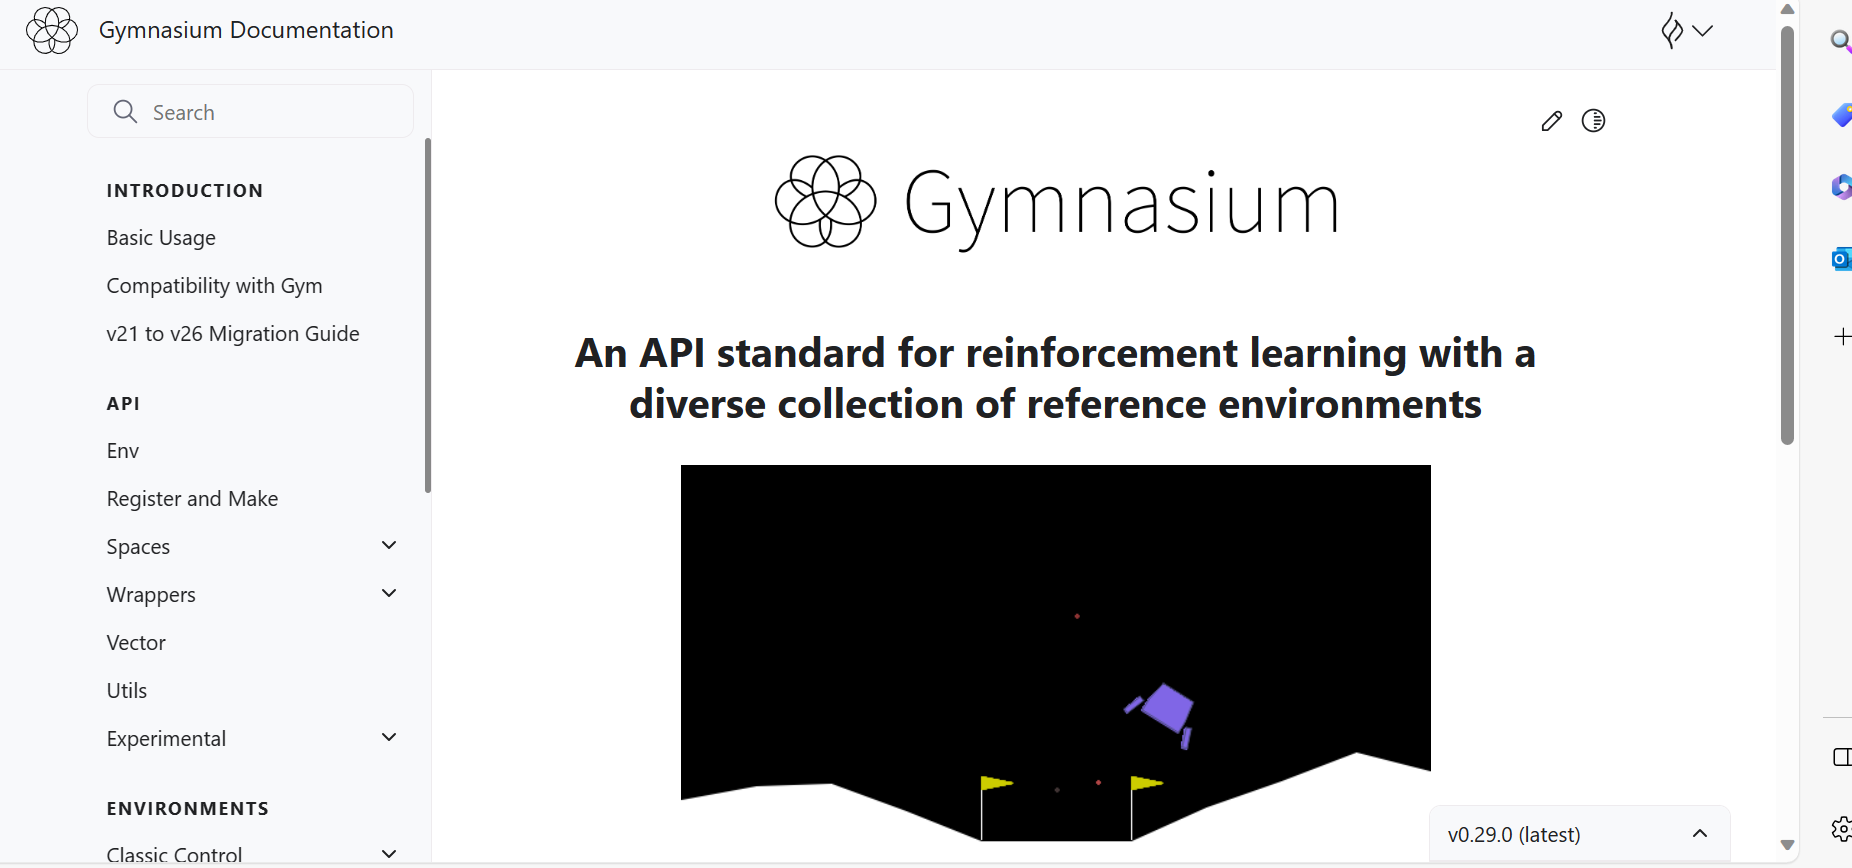

## 1. Instalación

In [1]:
# Instalar la versión 0.17.3 de OpenAI Gym para poder usar el comando "render".
%pip install gym==0.17.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.1 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654678 sha256=712f593d0f893e3852f94becb3eaf7852ce59c751a9c65a04259634f02f56967
  Stored in directory: /root/.cache/pip/wheels/28/27/f2/dcf9709f42d57a6a8c43578a5eebb50d95e1a3a9811621f75e
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
joblib 1.6.0 requires cloudpickle>=3

## 2. Entornos

OpenAi Gym posee distintos [entornos](https://gymnasium.farama.org/environments/classic_control/) simulados. Por favor tomarse unos minutos para echarles un vistazo.

------------------------------------------------------

Seguiremos el ejemplo con el entorno ***Frozen Lake (o "Lago Congelado")*** que es un Tablero Bidimensional similar al lo visto previamente.

https://gymnasium.farama.org/environments/toy_text/frozen_lake

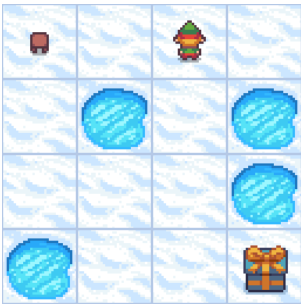

In [23]:
# Importar librería "gym" y crear el objeto "env" que contendrá el entorno
import gym
env = gym.make('FrozenLake-v0')


El ambiente puede configurarse en las siguientes dimensiones:

*   *map_name="4x4"*: cuadrícula 4x4
*   *map_name="8x8"*: cuadrícula de 8x8

El entorno tiene dos modos:

*   *is_slippery=False*: El agente siempre se mueve en la dirección prevista (determinista).
*   *is_slippery=True*: El agente no siempre puede moverse en la dirección prevista (estocástico).







In [24]:
#Ejemplo para revisar qué pasa si se carga este entorno:
env = gym.make("FrozenLake-v0", map_name="8x8", is_slippery=False)

Con el comando `render` podemos visualizar el entorno y su estado actual:

In [25]:
env.render()


SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG


Podemos personalizar la grilla de la siguiente manera:

In [11]:
desc=["0123", "4567", "8901", "2345"]
env = gym.make('FrozenLake-v0', desc=desc, is_slippery=True)
env.render()


0123
4567
8901
2345




*   `observation_space` es la variable que contiene el espacio de observaciones (en este caso es idéntico a la cantidad de estados)
*   `action_space` es la variable que contiene el espacio de acciones
*   `P` es la variable que contiene la función de transición:

In [26]:
S = env.observation_space
A = env.action_space
P = env.P
print(S)
print(A)
print(P) #Tiene tantas posiciones como número de estados. Se puede verificar con len(P)
print(len(P))

Discrete(64)
Discrete(4)
{0: {0: [(1.0, 0, 0.0, False)], 1: [(1.0, 8, 0.0, False)], 2: [(1.0, 1, 0.0, False)], 3: [(1.0, 0, 0.0, False)]}, 1: {0: [(1.0, 0, 0.0, False)], 1: [(1.0, 9, 0.0, False)], 2: [(1.0, 2, 0.0, False)], 3: [(1.0, 1, 0.0, False)]}, 2: {0: [(1.0, 1, 0.0, False)], 1: [(1.0, 10, 0.0, False)], 2: [(1.0, 3, 0.0, False)], 3: [(1.0, 2, 0.0, False)]}, 3: {0: [(1.0, 2, 0.0, False)], 1: [(1.0, 11, 0.0, False)], 2: [(1.0, 4, 0.0, False)], 3: [(1.0, 3, 0.0, False)]}, 4: {0: [(1.0, 3, 0.0, False)], 1: [(1.0, 12, 0.0, False)], 2: [(1.0, 5, 0.0, False)], 3: [(1.0, 4, 0.0, False)]}, 5: {0: [(1.0, 4, 0.0, False)], 1: [(1.0, 13, 0.0, False)], 2: [(1.0, 6, 0.0, False)], 3: [(1.0, 5, 0.0, False)]}, 6: {0: [(1.0, 5, 0.0, False)], 1: [(1.0, 14, 0.0, False)], 2: [(1.0, 7, 0.0, False)], 3: [(1.0, 6, 0.0, False)]}, 7: {0: [(1.0, 6, 0.0, False)], 1: [(1.0, 15, 0.0, False)], 2: [(1.0, 7, 0.0, False)], 3: [(1.0, 7, 0.0, False)]}, 8: {0: [(1.0, 8, 0.0, False)], 1: [(1.0, 16, 0.0, False)], 2: [(

Para conocer la funicón de transición partiendo de un estado `s` y tomando una acción `a`, se puede valuar la funicón en un punto.

Ejemplo:

Estado actual: *s=14*

Acción: *a=2*: #A2 = derecha

In [28]:
P[14][2]

[(1.0, 15, 0.0, False)]

Resultados:

- `(0.33, 14, 0.0, False)`: Probabilidad **0.33** de permanecer en el estado **14**, obteniendo una recompensa de **0.0** y el estado al que llegaría es (`False`) por lo que se entiende que no es terminal.

- `(0.33, 15, 1.0, True)`: Probabilidad **0.33** de llegar al estado **15**, obteniendo una recompensa de **1.0** y el estado al que llegaría es (`True`) por lo que llegaría a un estado terminal.

- `(0.33, 10, 0.0, False)`: Probabilidad **0.33** de permanecer en el estado **10**, obteniendo una recompensa de **0.0** y el estado al que llegaría es (`False`), el cual no es un estado terminal.

## 3. Interacción con el entorno

In [52]:
s = env.reset()
print(s)
env.render()

0

SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG


`step` ejecuta una acción del Agente dentro del Entorno.

Como habrá una transición de estado, muestra:
- observation (el nuevo estado, *s'*)
- reward (la recompensa obtenida, *R*)
- done ("*True*" si el episodio terminó)
- info (datos adicionales que dependen del entorno)

In [48]:
# Seleccionar una acción aleatoria
a = env.action_space.sample()
print('Acción:',a)

#Recordar que:
print('Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba')

Acción: 1
Acciones: 0-> Izquierda, 1-> Abajo, 2-> Derecha, 3-> Arriba


In [55]:
# Aplicar step
s, r, done, info = env.step(a)

print(f'Nuevo estado: {s}')
print(f'Recompensa: {r}')
print(f'¿Fin del episodio?: {done}')
print(f'Información adicional: {info}')

Nuevo estado: 24
Recompensa: 0.0
¿Fin del episodio?: False
Información adicional: {'prob': 1.0}


In [56]:
# Renderizar el entorno actualizado
env.render()

  (Down)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG



`reset` reinicia el entorno al estado inicial y retorna el valor de dicho estado:

In [57]:
s = env.reset()
print(s)
env.render()

0

SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG


Comentario final:

La v0 es la versión inicial desarrollada.

Existen versiones posteriores ( ej. v1)que resuelven algunos problemas de bugs relacionados con el sistema de recompensa, aunque hay funciones que ya no están disponibles (como por ejemplo `render`)

Ver más en:

https://gymnasium.farama.org/environments/toy_text/frozen_lake/